In [1]:
import pandas as pd 
df = pd.read_csv('Pictures/weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [2]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

# Create a DataFrame for columns that contain missing values only

In [3]:
missing = df.isnull().sum()
missing_list = missing[missing>0]
df_missing = pd.DataFrame(missing_list , columns = ['misssing'])

In [4]:
df_missing

,misssing
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566
WindDir3pm,4228
WindSpeed9am,1767


## Analyze Missing Values Distribution and Their Impact on the Dataset

Import visualization libraries and create charts to identify the columns with the highest number of missing values, while also measuring the overall percentage of missing values in the dataset to evaluate their impact on data quality and preprocessing decisions.

In [5]:
import nbformat
import plotly.express as px

In [6]:
px.pie(df_missing , values = 'misssing' , names = df_missing.index)

In [7]:
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [8]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [9]:
num_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [10]:
cat_cols

['Date',
 'Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

## Handling Missing Values in Categorical Columns

After analyzing the distribution of missing values, it was found that the overall percentage of missing data in the dataset was relatively low.  
Because the impact of these missing values on the dataset was not significant, a simple and practical imputation strategy was applied.

For categorical columns, missing values were replaced with the **most frequent value (mode)** in each column.  
This approach helps preserve the distribution of the data while avoiding the loss of rows or information.

Therefore, the next step was to identify the most frequent category in each categorical column and use it to fill the missing values.

In [11]:
df['WindGustDir'].value_counts()

WindGustDir
W      9915
SE     9418
N      9313
SSE    9216
E      9181
S      9168
WSW    9069
SW     8967
SSW    8736
WNW    8252
NW     8122
ENE    8104
ESE    7372
NE     7133
NNW    6620
NNE    6548
Name: count, dtype: int64

In [12]:
df['WindGustDir'].isnull().sum()

np.int64(10326)

In [13]:
df['WindGustDir'] = df['WindGustDir'].fillna('w')

In [14]:
df['WindGustDir'].isnull().sum()

np.int64(0)

In [15]:
df[cat_cols].isnull().sum()

Date                0
Location            0
WindGustDir         0
WindDir9am      10566
WindDir3pm       4228
RainToday        3261
RainTomorrow     3267
dtype: int64

In [16]:
df['WindDir9am'].value_counts()

WindDir9am
N      11758
SE      9287
E       9176
SSE     9112
NW      8749
S       8659
W       8459
SW      8423
NNE     8129
NNW     7980
ENE     7836
NE      7671
ESE     7630
SSW     7587
WNW     7414
WSW     7024
Name: count, dtype: int64

In [17]:
df['WindDir9am'] = df['WindDir9am'].fillna('n')

In [18]:
df['WindDir9am'].isnull().sum()

np.int64(0)

In [19]:
df['WindDir3pm'].value_counts()

WindDir3pm
SE     10838
W      10110
S       9926
WSW     9518
SSE     9399
SW      9354
N       8890
WNW     8874
NW      8610
ESE     8505
E       8472
NE      8263
SSW     8156
NNW     7870
ENE     7857
NNE     6590
Name: count, dtype: int64

In [20]:
df['WindDir3pm'] = df['WindDir9am'].fillna('SE')

In [21]:
df['WindDir3pm'].isnull().sum()

np.int64(0)

In [22]:
df['RainToday'].value_counts()

RainToday
No     110319
Yes     31880
Name: count, dtype: int64

In [23]:
df['RainToday'] = df['RainToday'].fillna('No')

In [24]:
df['RainToday'].isnull().sum()

np.int64(0)

In [25]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [26]:
df['RainTomorrow'] = df['RainTomorrow'].fillna('No')

In [27]:
df['RainTomorrow'].isnull().sum()

np.int64(0)

Missing values were handled in all categorical columns.

In [28]:
df[cat_cols].isnull().sum()

Date            0
Location        0
WindGustDir     0
WindDir9am      0
WindDir3pm      0
RainToday       0
RainTomorrow    0
dtype: int64

In [29]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir          0
WindGustSpeed    10263
WindDir9am           0
WindDir3pm           0
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday            0
RainTomorrow         0
dtype: int64

In [30]:
missing = df.isnull().sum()
missing_list = missing[missing>0]
df_missing = pd.DataFrame(missing_list , columns = ['misssing'])

In [31]:
px.pie(df_missing , values = 'misssing' , names = df_missing.index)

## Handling Missing Values in Numerical Columns

Missing values in numerical features were handled using **SimpleImputer**.  
For this project, the **median** strategy was selected instead of the mean because several weather-related numerical features may contain **outliers** or skewed distributions.

Unlike the mean, the median is **less sensitive to extreme values**, which makes it a more robust choice for imputing missing data in real-world weather measurements such as rainfall, wind speed, evaporation, and pressure.

Therefore, missing values in all numerical columns were filled using the **median** of each feature to preserve the overall structure of the data while reducing the effect of unusual observations.

In [32]:
from sklearn.impute import SimpleImputer

In [33]:
sm = SimpleImputer(strategy = 'median')

In [34]:
after_simple = sm.fit_transform(df[num_cols])

In [35]:
df_sm = pd.DataFrame(after_simple , columns = sm.feature_names_in_)

In [36]:
df[num_cols] = df_sm

In [37]:
df[num_cols].isnull().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

## Final Missing Values Check
All missing values in the dataset have been successfully handled.

In [38]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [39]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


encoding<!--  -->

## Extracting Year, Month, and Day from the Date Column

The `Date` column was converted into datetime format, then split into three separate features: **year**, **month**, and **day**.  
This makes the date information easier for the model to understand, then the original `Date` column was dropped.

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

## Encoding Categorical Features

For binary categorical columns such as `RainToday` and `RainTomorrow`, **Label Encoding** was used since these features contain only two categories.

For categorical columns with multiple categories such as `Location`, `WindGustDir`, `WindDir9am`, and `WindDir3pm`, **One-Hot Encoding** was applied to convert them into numerical form without creating an artificial order between categories.

In [41]:
from sklearn.preprocessing import  OneHotEncoder , LabelEncoder


In [42]:
la = LabelEncoder()

In [43]:
df['RainToday'] = la.fit_transform(df['RainToday'])

In [44]:
df['RainTomorrow'] = la.fit_transform(df['RainTomorrow'])

In [45]:
ohe = OneHotEncoder(handle_unknown = 'ignore')

In [46]:
location = ohe.fit_transform(df[['Location']]).toarray()

In [47]:
loc_df = pd.DataFrame(location , columns = ohe.get_feature_names_out())

In [48]:
WindGustDir = ohe.fit_transform(df[['WindGustDir']]).toarray()

In [49]:
WindGustDir_df = pd.DataFrame(WindGustDir , columns = ohe.get_feature_names_out())

In [50]:
WindDir9am = ohe.fit_transform(df[['WindDir9am']]).toarray()

In [51]:
WindGust9am_df = pd.DataFrame(WindDir9am , columns = ohe.get_feature_names_out())

In [52]:
WindDir3pm = ohe.fit_transform(df[['WindDir3pm']]).toarray()

In [53]:
WindDir3pm_df = pd.DataFrame(WindDir3pm, columns = ohe.get_feature_names_out())

In [54]:
df = df.join(loc_df)

In [55]:
df = df.join(WindGustDir_df)

In [56]:
df = df.join(WindGust9am_df)

In [57]:
df = df.join(WindDir3pm_df)

In [58]:
cols_drop = ['Location', 'WindGustDir', 'WindDir9am' , 'WindDir3pm']

In [59]:
df.drop(cols_drop , axis = 1 , inplace = True)

In [60]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_n
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Columns: 121 entries, MinTemp to WindDir3pm_n
dtypes: float64(116), int32(3), int64(2)
memory usage: 132.6 MB


## Simplified One-Hot Encoding Approach

The code below provides a shorter and cleaner way to apply **One-Hot Encoding** to multiple categorical columns at once using `pd.get_dummies()`.

Although the same preprocessing step was implemented manually above for learning purposes and to understand the encoding process in detail, this version is more practical and concise for real projects.

It performs the same task of converting the selected categorical features into numerical binary columns, while reducing the amount of repeated code and making the workflow more efficient and readable.

In [62]:
# # df = pd.get_dummies(
#     df,
#     columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'],
#     drop_first=True
# )

## Data Splitting and Scaling

The dataset was split into input features (`X`) and target labels (`y`), with `RainTomorrow` used as the prediction target.

Next, the data was divided into training and testing sets using `train_test_split()`, while `stratify=y` was used to maintain the same class distribution in both sets.

Finally, **StandardScaler** was applied to scale the feature values.  
This step is important for models such as **Logistic Regression** and **KNN**, as it helps place numerical features on a similar scale and improves model performance.

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x =df.drop('RainTomorrow' , axis = 1)
y =df['RainTomorrow']
xtrain , xtest , ytrain , ytest =train_test_split(x , y , shuffle = True ,test_size = .2 , random_state= 42 , stratify = y)

sc = StandardScaler()
xtrain_scaled = sc.fit_transform(xtrain)
xtest_scaled = sc.transform(xtest)

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
lr = LogisticRegression(max_iter=1000)

In [66]:
lr.fit(xtrain_scaled , ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
print(lr.score(xtrain_scaled , ytrain))

0.8477588340437233


In [68]:
print(lr.score(xtest_scaled , ytest))

0.8509555891654063


In [69]:
y_pred = lr.predict(xtest_scaled)

## Confusion Matrix Interpretation

The confusion matrix provides a detailed view of the model’s classification performance:

- **TN = 21552** → The model correctly predicted **no rain**.
- **FP = 1165** → The model predicted **rain**, but it actually did **not rain**.
- **FN = 3171** → The model predicted **no rain**, but it actually **rained**.
- **TP = 3204** → The model correctly predicted **rain**.

### Interpretation
The model performs very well in identifying **days without rain**, as shown by the high number of true negatives.  
It is also able to detect a reasonable number of rainy days, but it still misses some actual rain cases, as reflected in the false negatives.

Overall, the model shows **good classification performance**, with stronger accuracy in predicting **no-rain days** than rainy days.

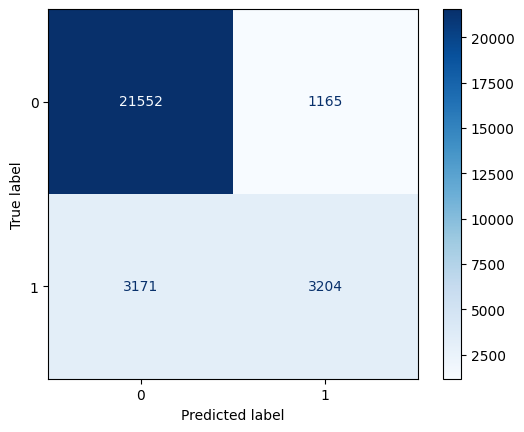

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()